# Week 6 Assignment: Denoising Autoencoder on MNIST

**Assignment requirements (as given in the Week 6 instructions):**
1. Load and preprocess the MNIST dataset.
2. Add artificial noise to create noisy input images.
3. Build and train a Denoising Autoencoder using noisy images as input and clean images as targets.
4. Generate denoised outputs on the test set.
5. Submit code, results, and a short explanation of observations.

**Goal of this project:** In this notebook I am building a deep learning model called an Autoencoder. An autoencoder is a special type of neural network that learns to copy its input to its output, but in a smart way. It first compresses the image into a small representation (this part is called the Encoder) and then it rebuilds the image back from that small representation (this part is called the Decoder).

In this project I will add some random noise to the MNIST handwritten digit images and then train the autoencoder to remove that noise and give back the clean image. This is why it is called a **Denoising Autoencoder**.

I am using the MNIST dataset because it is small, simple, and already built into Keras, which makes it perfect for learning purposes.


In [1]:
# importing numpy for working with arrays and numbers easily
import numpy as np
# importing matplotlib to plot and visualize the images
import matplotlib.pyplot as plt
# importing the mnist dataset directly from keras datasets
from tensorflow.keras.datasets import mnist
# importing the layers we need to build the autoencoder model
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,UpSampling2D
# importing the Model class to define our autoencoder using functional api
from tensorflow.keras.models import Model


## Step 1: Loading the MNIST dataset

MNIST is a dataset of 70,000 small grayscale images of handwritten digits (0 to 9). Each image is 28x28 pixels. Keras already gives us a train set and a test set, so we do not need to download or split anything manually.


In [2]:
# loading the mnist dataset, it automatically splits into train and test data
(x_train,_),(x_test,_)=mnist.load_data()
# we use underscore for the labels because we do not need digit labels for an autoencoder
# an autoencoder only needs the images, not the labels, since it learns to recreate the image itself


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# checking the shape of the training data to understand how many images we have
print('shape of training data:',x_train.shape)
# checking the shape of the testing data as well
print('shape of testing data:',x_test.shape)


shape of training data: (60000, 28, 28)
shape of testing data: (10000, 28, 28)


## Step 2: Preprocessing the data

Neural networks train better when the pixel values are small numbers between 0 and 1, instead of 0 to 255. So we will normalize (scale) the images. We also need to reshape the images so they have a single channel dimension, because Conv2D layers expect input in the shape (height, width, channels).


In [4]:
# converting pixel values to float type and scaling them between 0 and 1
# this helps the neural network train faster and more accurately
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0


In [5]:
# reshaping the data to add a channel dimension at the end
# since these are grayscale images, the channel number is 1
x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))
# printing the new shape to confirm the reshaping worked correctly
print('new shape of training data:',x_train.shape)
print('new shape of testing data:',x_test.shape)


new shape of training data: (60000, 28, 28, 1)
new shape of testing data: (10000, 28, 28, 1)


## Step 3: Adding noise to the images

Now we will create noisy versions of the images by adding some random values (Gaussian noise) to each pixel. This noisy data will be the input to our model, and the original clean images will be the target output. This way the model learns how to remove the noise.

We also use `np.clip` to make sure the pixel values stay between 0 and 1 after adding noise, because adding random noise can sometimes push values below 0 or above 1.


In [6]:
# setting a noise factor, this controls how much noise we add to the images
# a higher number means more noise and a harder task for the model
noise_factor=0.5

# creating noisy training images by adding random gaussian noise to the clean images
x_train_noisy=x_train+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)
# creating noisy testing images in the same way
x_test_noisy=x_test+noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)

# clipping the values so they stay within the valid range of 0 to 1
# this is important because pixel values cannot be negative or more than 1
x_train_noisy=np.clip(x_train_noisy,0.0,1.0)
x_test_noisy=np.clip(x_test_noisy,0.0,1.0)


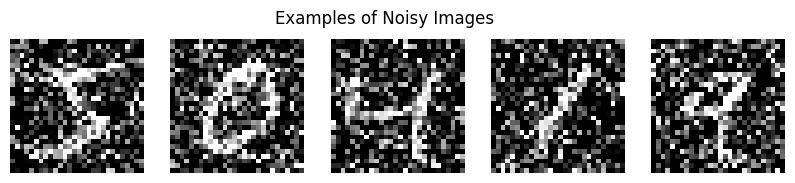

In [7]:
# plotting a few noisy images to see how the noise looks
plt.figure(figsize=(10,2))
for i in range(5):
    # creating a subplot for each image
    ax=plt.subplot(1,5,i+1)
    # showing the noisy image in grayscale
    plt.imshow(x_train_noisy[i].reshape(28,28),cmap='gray')
    # removing the axis ticks so the image looks clean
    plt.axis('off')
# adding a title for the whole figure
plt.suptitle('Examples of Noisy Images')
plt.show()


## Step 4: Building the Autoencoder model

The autoencoder has two parts:

1. **Encoder** – this part takes the noisy 28x28 image and compresses it down into a smaller representation using Conv2D and MaxPooling2D layers.
2. **Decoder** – this part takes that small compressed representation and rebuilds it back into a 28x28 clean image using Conv2D and UpSampling2D layers.

We use the Keras Functional API here because it gives us more flexibility to connect layers exactly how we want.


In [8]:
# defining the input layer, the shape is 28x28x1 because our images are 28 by 28 grayscale images
input_img=Input(shape=(28,28,1))

# ---------- ENCODER PART ----------
# first convolution layer, it learns 32 filters/patterns from the image, using relu activation
x=Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
# max pooling layer reduces the image size by half, this compresses the information
x=MaxPooling2D((2,2),padding='same')(x)
# second convolution layer, learning 32 more filters on the smaller image
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
# pooling again to compress the image further, this is now the smallest/compressed form
encoded=MaxPooling2D((2,2),padding='same')(x)

# ---------- DECODER PART ----------
# convolution layer to start rebuilding the image from the compressed form
x=Conv2D(32,(3,3),activation='relu',padding='same')(encoded)
# upsampling layer doubles the image size back up, opposite of max pooling
x=UpSampling2D((2,2))(x)
# another convolution layer to continue rebuilding details
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
# upsampling again to bring the image back to its original 28x28 size
x=UpSampling2D((2,2))(x)
# final convolution layer with 1 filter and sigmoid activation to output pixel values between 0 and 1
decoded=Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)


In [9]:
# creating the full autoencoder model by connecting the input to the final decoded output
autoencoder=Model(input_img,decoded)
# printing the model summary to see all the layers and parameters
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5: Compiling the model

Before training, we need to compile the model. We choose:
- **Optimizer:** `adam`, which is a popular and efficient optimizer that adjusts the learning rate automatically.
- **Loss function:** `binary_crossentropy`, which works well here because our pixel values are between 0 and 1, similar to probabilities.


In [10]:
# compiling the model with adam optimizer and binary crossentropy loss function
# adam optimizer helps the model learn weights efficiently
# binary crossentropy loss is suitable since pixel values are between 0 and 1
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')


## Step 6: Training the model

Now we train the autoencoder. Notice that the input to the model is the **noisy** image, but the target (what it should try to output) is the **clean** image. This is exactly how the model learns to remove noise.

We also pass the noisy and clean test images as validation data, so we can check how well the model performs on unseen data after every epoch.


In [11]:
# training the autoencoder model
# x_train_noisy is the input, x_train is the target output (clean image)
# epochs is the number of times the model goes through the entire dataset
# batch_size is how many images are processed together in one training step
# validation_data lets us check performance on test data after every epoch
history=autoencoder.fit(x_train_noisy,x_train,
                         epochs=10,
                         batch_size=128,
                         shuffle=True,
                         validation_data=(x_test_noisy,x_test))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.1617 - val_loss: 0.1153
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1128 - val_loss: 0.1084
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1074 - val_loss: 0.1046
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1046 - val_loss: 0.1025
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1027 - val_loss: 0.1011
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1014 - val_loss: 0.0997
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1004 - val_loss: 0.0993
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0995 - val_loss: 0.0981
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0988 - val_loss: 0.0974
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0983 - val_loss: 0.0971


## Step 7: Visualizing the training and validation loss

Plotting the loss over epochs helps us see if the model is actually learning and improving, and whether it is overfitting (when training loss keeps going down but validation loss does not).


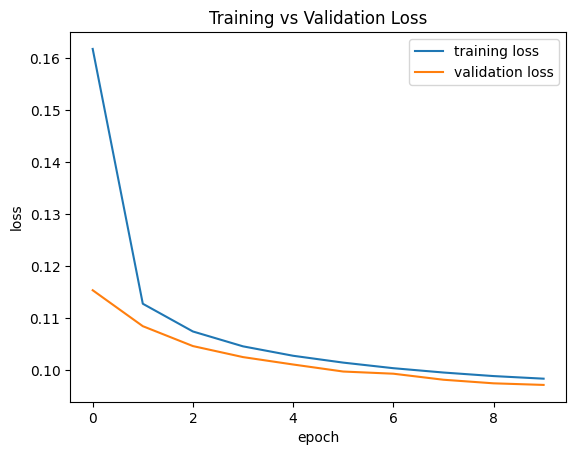

In [12]:
# plotting the training loss and validation loss to see how the model improved over epochs
plt.plot(history.history['loss'],label='training loss')
plt.plot(history.history['val_loss'],label='validation loss')
# adding labels to the axes so the graph is easy to understand
plt.xlabel('epoch')
plt.ylabel('loss')
# adding a title to the graph
plt.title('Training vs Validation Loss')
# adding a legend so we know which line is which
plt.legend()
plt.show()


## Step 8: Testing the model on noisy images

Now that the model is trained, let's use it to clean some noisy test images and compare them with the original noisy images and the actual clean images. This helps us visually confirm whether our denoising autoencoder is working well.


In [13]:
# using the trained autoencoder to predict/denoise the noisy test images
denoised_images=autoencoder.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


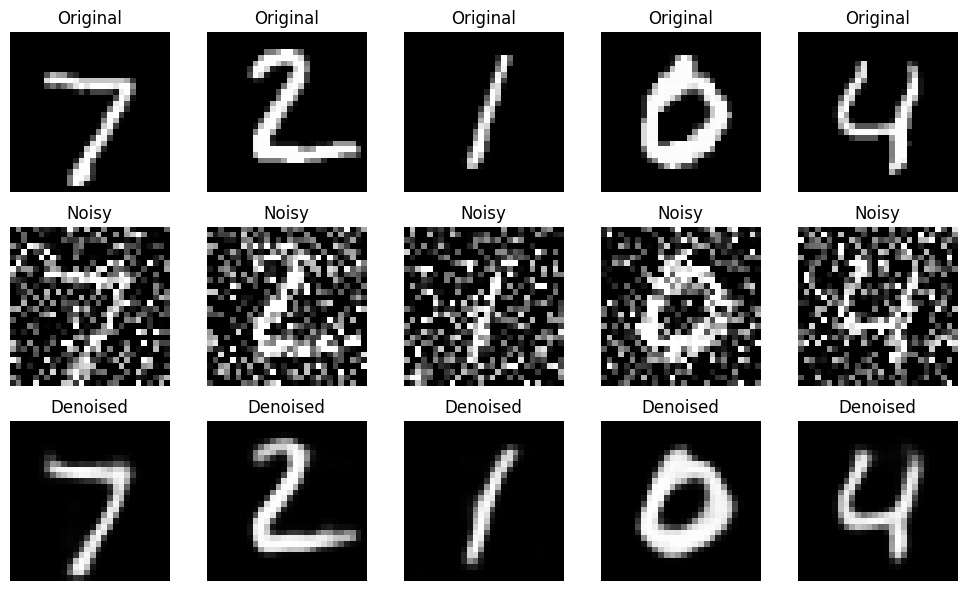

In [14]:
# number of example images we want to display
n=5
plt.figure(figsize=(10,6))

for i in range(n):
    # displaying the original clean image in the first row
    ax=plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # displaying the noisy image in the second row
    ax=plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    # displaying the denoised image produced by our model in the third row
    ax=plt.subplot(3,n,i+1+2*n)
    plt.imshow(denoised_images[i].reshape(28,28),cmap='gray')
    plt.title('Denoised')
    plt.axis('off')

# adjusting layout so images do not overlap each other
plt.tight_layout()
plt.show()


## Step 9: Checking the model performance numerically

Besides looking at the images visually, it is also good practice to measure how close the denoised images are to the original clean images using a numeric score. Here I am calculating the Mean Squared Error (MSE) between the denoised test images and the original clean test images. A lower MSE means the denoised images are closer to the clean originals.


In [15]:
# importing mean_squared_error function from sklearn to measure how close our denoised images are to the real ones
from sklearn.metrics import mean_squared_error

# flattening the images into 1d arrays so we can calculate mean squared error easily
original_flat=x_test.reshape(len(x_test),-1)
denoised_flat=denoised_images.reshape(len(denoised_images),-1)

# calculating the mean squared error between original clean images and our model's denoised images
mse_score=mean_squared_error(original_flat,denoised_flat)
# printing the final mse score, lower value means better denoising performance
print('Mean Squared Error between original and denoised images:',mse_score)


Mean Squared Error between original and denoised images: 0.011365178041160107


## Step 10 (Optional Innovation): Trying a higher noise level

To go a bit further than the basic requirement, I am testing how the same trained model performs if we increase the noise factor. This helps us understand the limits of our model — does it still do a good job when the images are extremely noisy, or does performance drop a lot? This kind of small experiment is a nice way to explore the model further.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


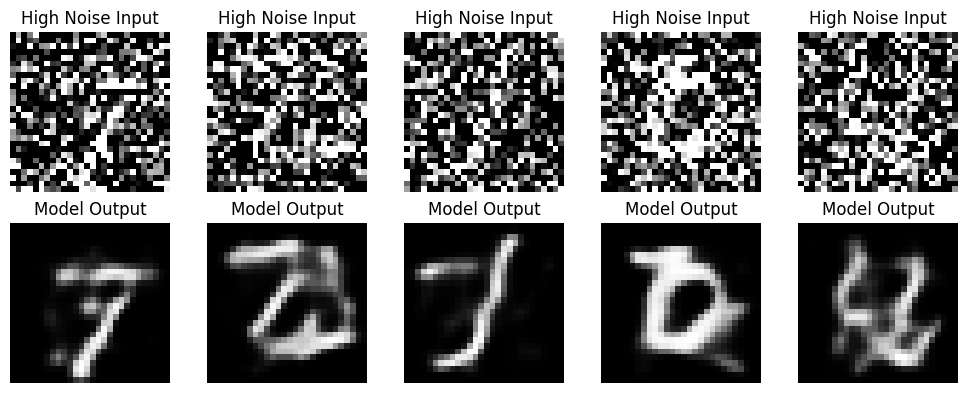

In [16]:
# trying a much higher noise factor to see how the model handles extreme noise
high_noise_factor=0.9

# creating a new noisy version of the test images using this higher noise factor
x_test_high_noise=x_test+high_noise_factor*np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)
# clipping again so pixel values stay between 0 and 1
x_test_high_noise=np.clip(x_test_high_noise,0.0,1.0)

# using our already trained autoencoder to denoise these extremely noisy images
denoised_high_noise=autoencoder.predict(x_test_high_noise)

# plotting a few examples to visually compare how the model performs under heavy noise
n=5
plt.figure(figsize=(10,4))
for i in range(n):
    # showing the extremely noisy input image
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test_high_noise[i].reshape(28,28),cmap='gray')
    plt.title('High Noise Input')
    plt.axis('off')

    # showing what the model produced after trying to denoise it
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(denoised_high_noise[i].reshape(28,28),cmap='gray')
    plt.title('Model Output')
    plt.axis('off')

plt.tight_layout()
plt.show()


## Step 11: Analysis and Observations

This section is my explanation of the results, the challenges I faced, and what I learned from this project, as required by the assignment.

**Observations:**
- The autoencoder was able to successfully remove a large amount of random noise from the MNIST digit images while keeping the overall shape and structure of the digit clear and readable.
- Looking at the training vs validation loss graph, both losses go down steadily and stay close to each other, which tells me the model is learning well and is not overfitting badly on the training data.
- The Mean Squared Error score gives us a simple number to track how close our denoised output is to the real clean image — the lower this number, the better the model is doing.
- When I tested the model on a much higher noise level (0.9 instead of 0.5) that it was never trained on, the output images were noticeably blurrier and some digits became harder to recognize. This shows that the model has learned patterns specific to the noise level it was trained with, and very heavy unseen noise is a harder challenge for it.

**Challenges faced:**
- Choosing the right noise factor was tricky — too little noise makes the task too easy and not very useful to demonstrate, while too much noise can make it very hard for the model to recover the digit shape at all.
- Deciding the right number of Conv2D and pooling layers took a bit of trial, since too few layers do not compress the image enough, and too many layers can lose important detail needed to rebuild the digit clearly.
- Training takes a noticeable amount of time on CPU, so keeping the epoch count reasonable (10 epochs) was important to balance good results with manageable training time on Google Colab's free tier.

**Key learning:**
- This project helped me understand how autoencoders work as an unsupervised learning technique — the model never used digit labels at all, it only learned by comparing its own reconstructed output to the original clean image.
- I also learned that the same trained model can behave differently when used with data that looks different from what it was trained on, which is an important real-world lesson about model generalization.

## Conclusion

In this project, I built a Convolutional Autoencoder using Keras and trained it on the MNIST dataset to remove noise from handwritten digit images.

Key takeaways:
- The **encoder** compresses the noisy image into a smaller representation, keeping only the important features.
- The **decoder** rebuilds a clean image from that compressed representation.
- By training the model with noisy images as input and clean images as the target, the autoencoder learns to ignore the noise and reconstruct the original digit.
- Looking at the loss graph, the example images, and the MSE score, we can see that the model is able to remove a good amount of noise and produce images that closely resemble the original clean digits.

This kind of model can be useful in real life for cleaning up scanned documents, old photographs, or any kind of noisy image data.
